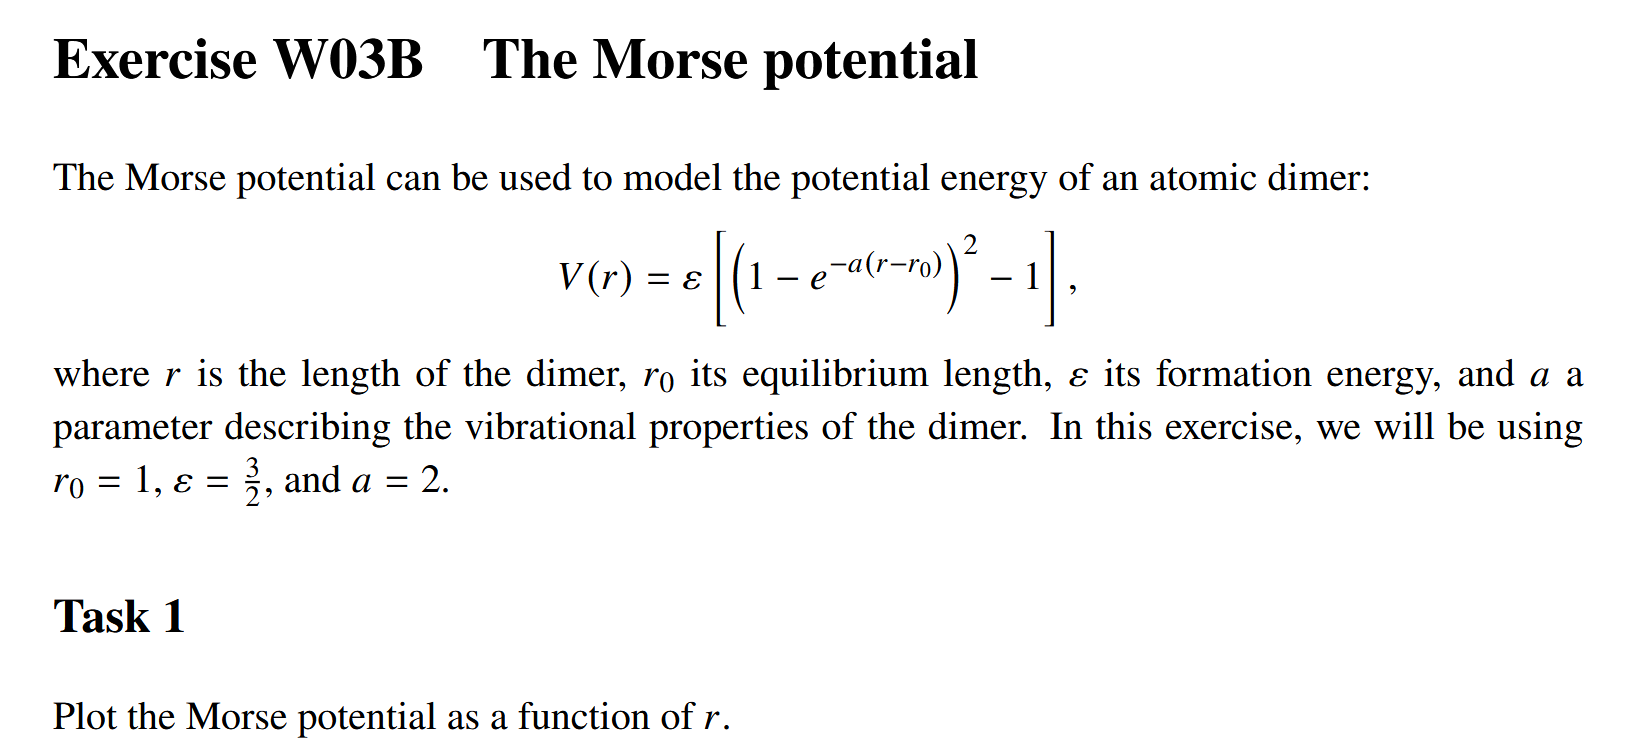

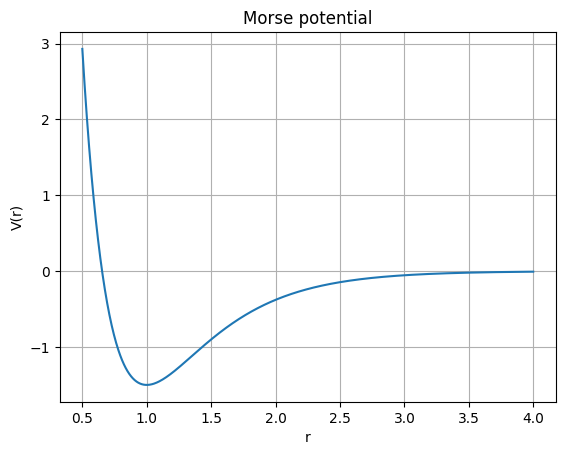

In [4]:
import numpy as np
import matplotlib.pyplot as plt 

def V(r, ε=3/2, r0=1, a=2): 
    return ε*((1 - np.exp(-a*(r - r0)))**2 - 1)

x = np.linspace(0.5, 4, 1000)
plt.plot(x, V(x))
plt.title('Morse potential')
plt.xlabel('r')
plt.ylabel('V(r)')
plt.grid()
plt.show()

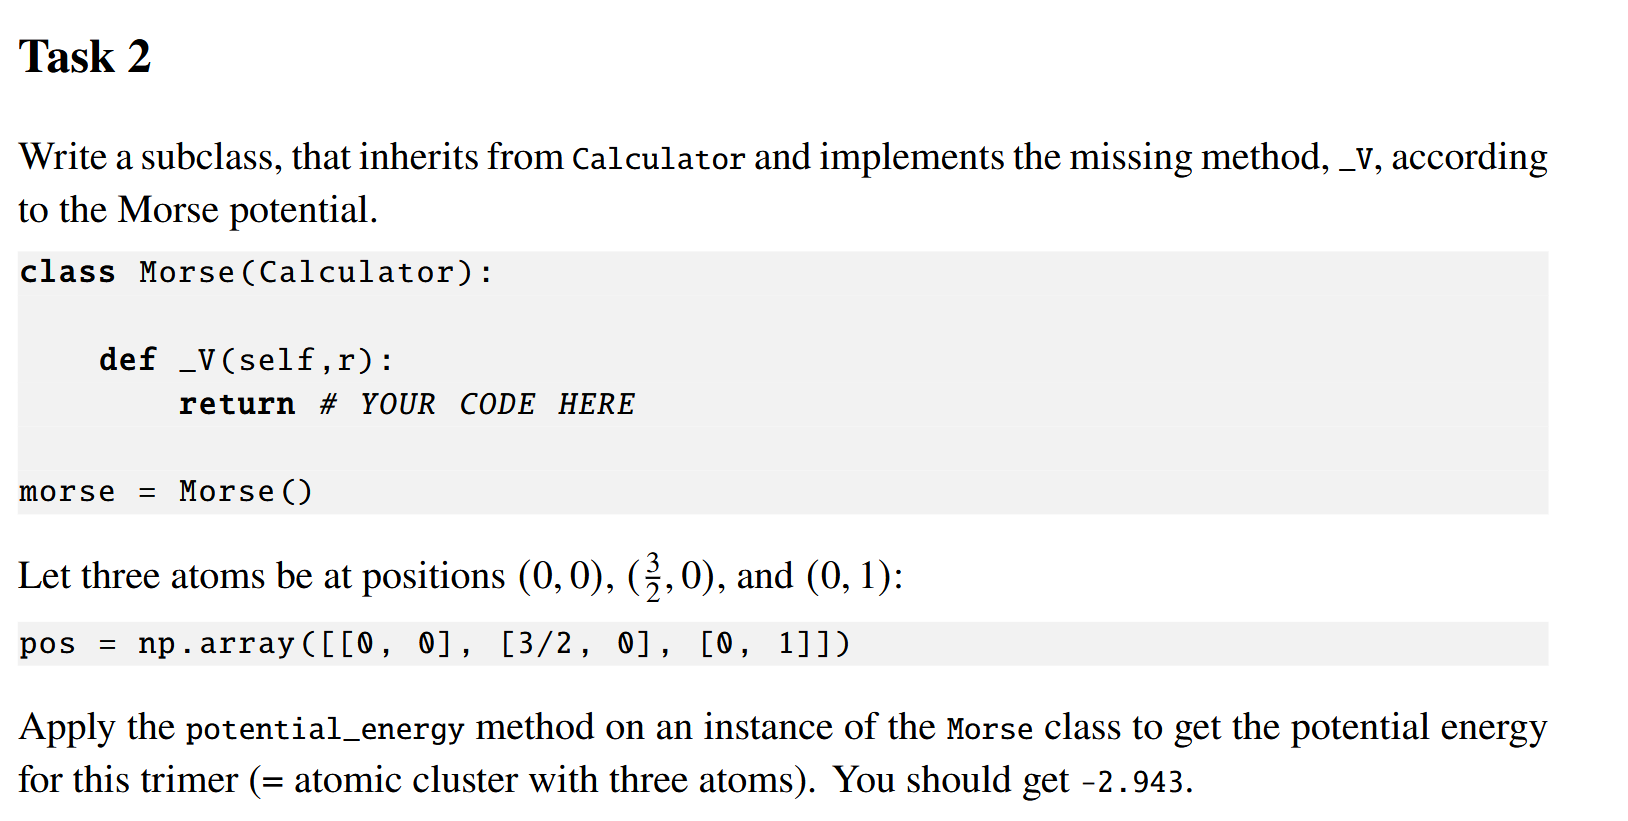

In [5]:
from scipy.spatial.distance import pdist
class Calculator ():
    def potential_energy(self , pos):
        return np.sum(self._V(pdist(pos)))

class Morse(Calculator):
    def __init__(self, r0=1, ε=3/2, a=2):
        self.r0 = r0
        self.ε = ε
        self.a = a

    def _V(self, r):
        return self.ε*((1 - np.exp(-self.a*(r - self.r0)))**2 - 1)

morse = Morse()

pos = np.array([[0,0], [3/2,0], [0,1]])

print(f'We get {morse.potential_energy(pos):.3f} for the potential')

We get -2.943 for the potential


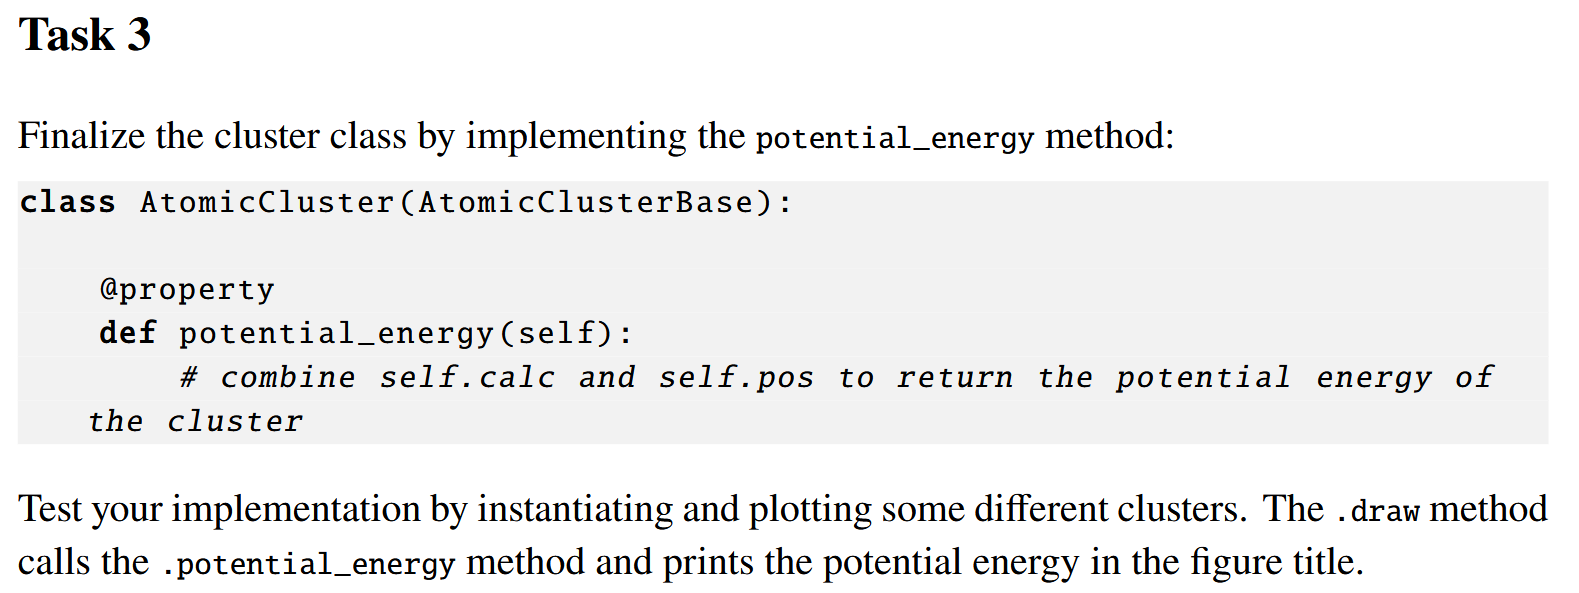

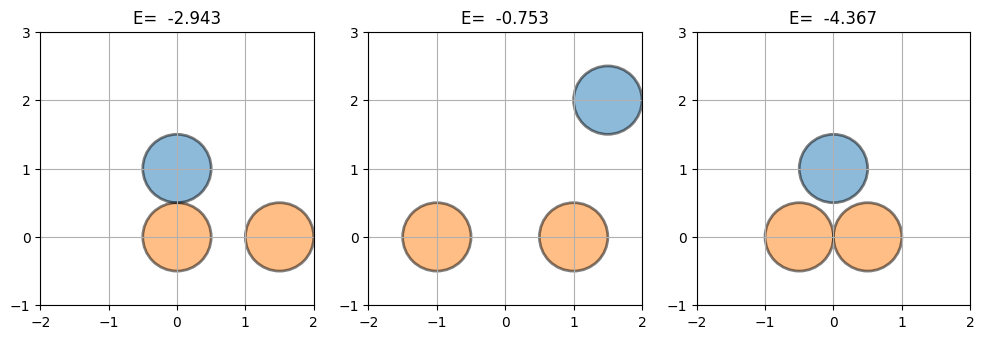

In [6]:
from week03 import AtomicClusterBase, nice_plot

class AtomicClusterBase(AtomicClusterBase):
    @property
    def potential_energy(self):
        return self.calc.potential_energy(self.pos)
        

fig , axes = plt. subplots (1,3, figsize =(12 ,4))
cluster0 = AtomicClusterBase(morse,pos =[[0, 0], [3/2, 0], [0, 1]], static=[True, True, False ])
cluster1 = AtomicClusterBase(morse,pos =[[-1, 0], [1, 0], [1.5, 2]], static=[True, True, False ])
cluster2 = AtomicClusterBase(morse,pos =[[-0.5, 0], [0.5, 0], [0, 1]], static=[True, True, False ])
for ax , cluster in zip(axes ,[ cluster0 , cluster1 , cluster2 ]):
    cluster.draw(ax)
    nice_plot(ax)

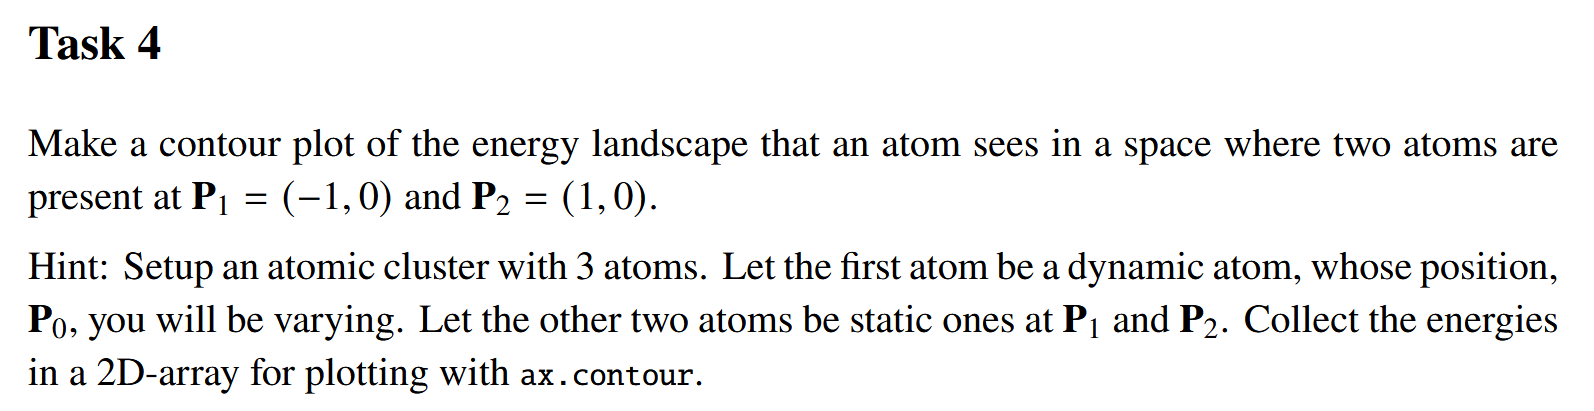

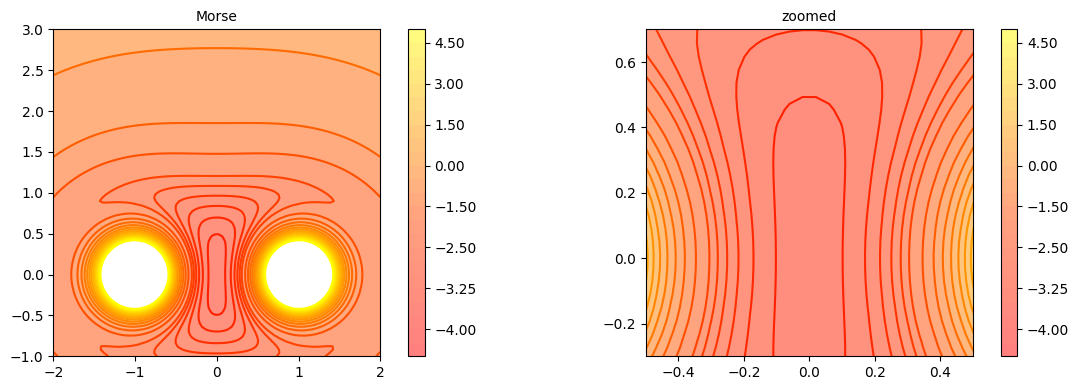

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pos0 = np.array([[0.0,0.0], [-1.0,0.0], [1.0,0.0]])

cluster = AtomicClusterBase(morse, pos=pos0, static=[False, True, True])

xs = np.linspace(-2, 2, 100)
ys = np.linspace(-1, 3, 100)

xd, yd = np.meshgrid(xs, ys)
zd = np.zeros_like(xd)

for i,j in np.ndindex(xd.shape):
    cluster.pos[0] = [xd[i, j], yd[i, j]]
    zd[i, j] = cluster.potential_energy

levels = list(np.arange(-4.5, -2, 0.25)) + list(np.arange(-2, 5.001, 0.5))

ax = axes[0]
ax.contour(xd, yd, zd, levels=levels, cmap='autumn')
color_map = ax.contourf(xd, yd, zd, levels=levels, alpha=0.5, cmap='autumn')

fig.colorbar(color_map, ax=ax)
ax.set_aspect('equal')
ax.set_title(str(cluster.calc.__class__.__name__), fontsize=10)

ax = axes[1]
ax.contour(xd, yd, zd, levels=levels, cmap='autumn')
color_map = ax.contourf(xd, yd, zd, levels=levels, alpha=0.5, cmap='autumn')

fig.colorbar(color_map, ax=ax)
ax.set_aspect('equal')
ax.set_title('zoomed', fontsize=10)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.3, 0.7)

plt.tight_layout()

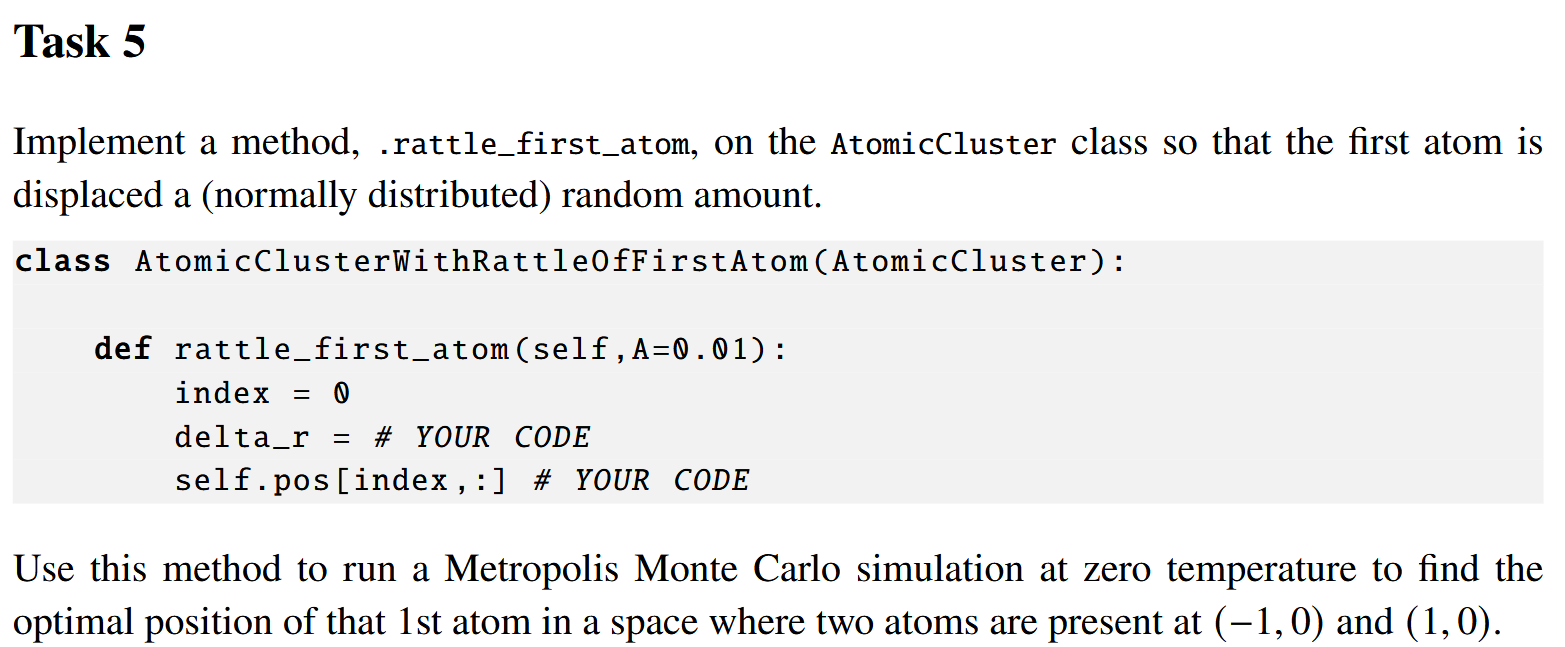

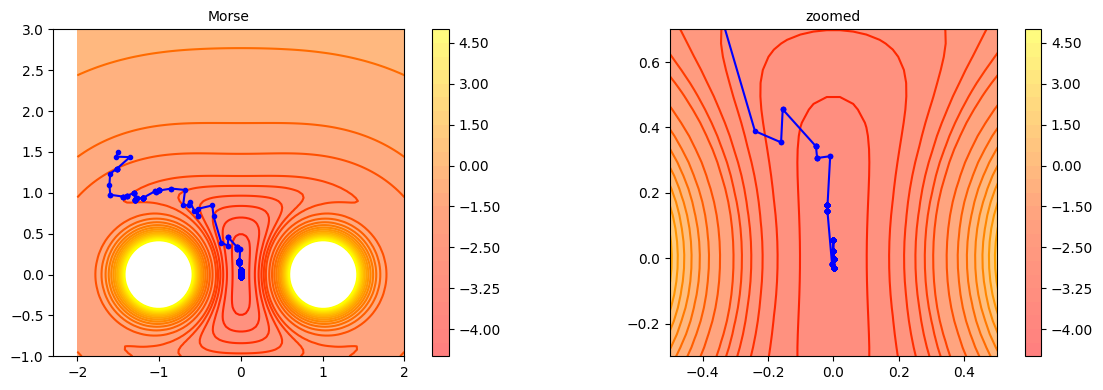

In [13]:
class AtomicClusterBase(AtomicClusterBase):
    def rattle_first_atom(self, A=0.1):
        index = 0 
        delta_r = np.random.normal(scale=A, size=2)
        self.pos[index,:] += delta_r

pos0[0] = [-1.5, 1.5]
cluster = AtomicClusterBase(morse, pos=pos0, static=[False, True, True])



def monte_carlo_quench(cluster, N):
    points = [cluster.get_positions()[0]]
    for _ in range(N):
        test = cluster.copy()
        test.rattle_first_atom()
        delta_E = test.potential_energy - cluster.potential_energy

        if delta_E < 0:
            cluster.set_positions(test.get_positions())

        points.append(cluster.get_positions()[0])
    return np.array(points).transpose()

points = monte_carlo_quench(cluster, N=2000)

# Remove any old trajectory lines from previous runs
for line in axes[0].lines:
    line.remove()
for line in axes[1].lines:
    line.remove()

axes[0].plot(points[0], points[1], 'b.-')
axes[1].plot(points[0], points[1], 'b.-')
fig

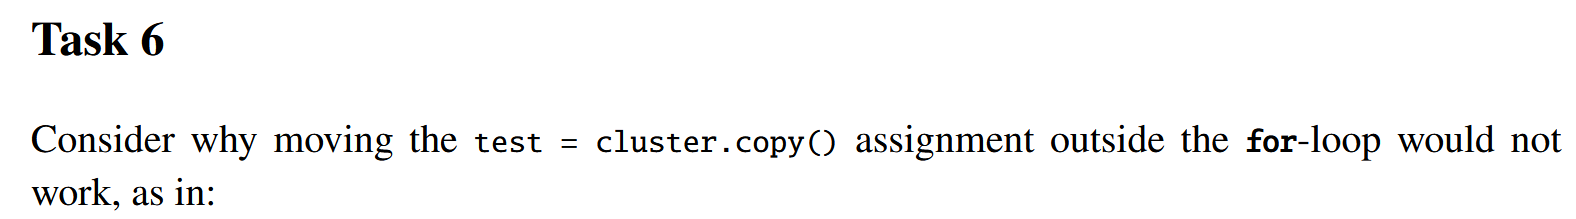

Because it will always test against the starting position and not reset after rattle which changes the position. 
So even if we dont accept the step it will rattle the atom further away. 